## **Análisis Exploratorio de Datos (EDA)**

### **Objetivo**

En esta etapa se realiza un análisis exploratorio del dataset consolidado construido durante la fase de ETL.

El objetivo es comprender la distribución de las variables, identificar patrones asociados a los siniestros fatales, evaluar la calidad de los datos y obtener información relevante para la etapa de modelado predictivo.

La unidad de análisis corresponde a un siniestro vial ocurrido en la Ciudad Autónoma de Buenos Aires durante el período 2019-2025.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Restablece el diseño de los gráficos al estilo por defecto
plt.style.use("default")

# Muestra todas las columnas del DataFrame sin recortes
pd.set_option("display.max_columns", None)

# Limita la visualización a un máximo de 100 filas
pd.set_option("display.max_rows", 100)

### **Carga del dataset**

Se carga el dataset analítico generado durante la fase de ETL.

Este archivo ya contiene una fila por siniestro y será utilizado como base para el análisis exploratorio.

In [2]:
# Cargar el dataset analítico generado en la fase de ETL

df = pd.read_csv(
    "../data_processed/siniestros_viales_modelado.csv",
    low_memory=False
)

df.head()

,id_siniestro,siniestro_fatal,fecha_siniestro,anio_siniestro,mes_siniestro,dia_siniestro,dia_semana,rango_horario,comuna_siniestro,tipo_de_via_siniestro,participantes_siniestro,modo_desplazamiento_victima,contraparte_siniestro,latitud_siniestro,longitud_siniestro,edad_promedio_victimas,sexo_victima_agregado
0,LC-2019-0000053,0,2019-01-01,2019,1,1,Tuesday,1,Comuna 8,AUTOPISTA,AUTO-UTILITARIO,AUTO,UTILITARIO,-34.669125,-58.443510,57.000000,M
1,LC-2019-0000647,0,2019-01-01,2019,1,1,Tuesday,18,Comuna 12,AVENIDA,MOTO-AUTO,MOTO,AUTO,-34.583403,-58.490436,54.000000,M
2,LC-2019-0000445,0,2019-01-01,2019,1,1,Tuesday,13,Comuna 11,NaN,AUTO-AUTO,AUTO,AUTO,-34.603255,-58.524662,40.333333,MIXTO
3,LC-2019-0000194,0,2019-01-01,2019,1,1,Tuesday,7,Comuna 9,NaN,AUTO-CAMION,AUTO,CAMION,-34.650156,-58.528413,33.000000,F
4,LC-2019-0000329,0,2019-01-01,2019,1,1,Tuesday,12,Comuna 4,NaN,AUTO-MOVIL,AUTO,MOVIL,-34.648387,-58.404748,23.000000,M


### **Calidad general del dataset**

Se revisan las dimensiones, los tipos de datos y la cantidad de valores faltantes del dataset final.

Esta revisión permite validar que el archivo exportado desde la fase de ETL conserva la estructura esperada antes de avanzar con el análisis exploratorio.

In [3]:
# Verificar cantidad de registros y variables del dataset

print("Cantidad de registros:", df.shape[0])
print("Cantidad de variables:", df.shape[1])

Cantidad de registros: 65818
Cantidad de variables: 17


In [4]:
# Revisar tipos de datos y cantidad de valores no nulos por variable

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65818 entries, 0 to 65817
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_siniestro                 65818 non-null  object 
 1   siniestro_fatal              65818 non-null  int64  
 2   fecha_siniestro              65818 non-null  object 
 3   anio_siniestro               65818 non-null  int64  
 4   mes_siniestro                65818 non-null  int64  
 5   dia_siniestro                65818 non-null  int64  
 6   dia_semana                   65818 non-null  object 
 7   rango_horario                65741 non-null  object 
 8   comuna_siniestro             62801 non-null  object 
 9   tipo_de_via_siniestro        53591 non-null  object 
 10  participantes_siniestro      65818 non-null  object 
 11  modo_desplazamiento_victima  65818 non-null  object 
 12  contraparte_siniestro        65818 non-null  object 
 13  latitud_siniestr

In [5]:
# Calcular cantidad y porcentaje de valores faltantes por variable

valores_faltantes = (
    pd.DataFrame({
        "cantidad": df.isna().sum(),
        "porcentaje": df.isna().mean() * 100
    })
    .sort_values("porcentaje", ascending=False)
)

valores_faltantes

,cantidad,porcentaje
edad_promedio_victimas,20559,31.236136
tipo_de_via_siniestro,12227,18.576985
longitud_siniestro,3031,4.605123
latitud_siniestro,3031,4.605123
comuna_siniestro,3017,4.583852
rango_horario,77,0.116989
contraparte_siniestro,0,0.000000
modo_desplazamiento_victima,0,0.000000
participantes_siniestro,0,0.000000
id_siniestro,0,0.000000


**Observaciones**

El dataset final contiene 65.818 registros y 17 variables, manteniendo las dimensiones definidas al finalizar la fase de ETL.

No se detectaron pérdidas de registros durante la exportación del dataset analítico.

Las variables presentan una combinación de datos numéricos y categóricos, predominando estas últimas debido a la naturaleza descriptiva de los siniestros.

Respecto de los valores faltantes, la variable con mayor proporción de ausencia es `edad_promedio_victimas` (31,2%), seguida por `tipo_de_via_siniestro` (18,6%). También se observan faltantes en las variables geográficas (`latitud_siniestro`, `longitud_siniestro`) y en `comuna_siniestro`, aunque en menor magnitud.

Estas ausencias serán analizadas con mayor detalle en una sección específica del EDA para evaluar posibles estrategias de tratamiento antes del modelado.

### **Distribución de la variable objetivo**

La variable objetivo del proyecto es `siniestro_fatal`.

Su valor es:

- 1: el siniestro presenta al menos una víctima fatal.
- 0: el siniestro no presenta víctimas fatales.

El objetivo de esta sección es analizar la distribución de clases y evaluar el posible desbalance del problema de clasificación.

Distribución absoluta:
siniestro_fatal
0    65129
1      689
Name: count, dtype: int64

Distribución porcentual:
siniestro_fatal
0    98.95
1     1.05
Name: proportion, dtype: float64


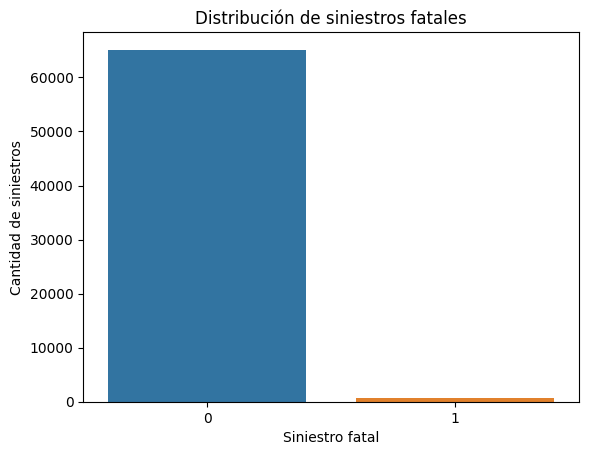

In [6]:
# Analizar la distribución de la variable objetivo

print("Distribución absoluta:")
print(df["siniestro_fatal"].value_counts())

print("\nDistribución porcentual:")
print(
    round(
        df["siniestro_fatal"].value_counts(normalize=True) * 100,
        2
    )
)

sns.countplot(
    data=df,
    x="siniestro_fatal"
)

plt.title("Distribución de siniestros fatales")
plt.xlabel("Siniestro fatal")
plt.ylabel("Cantidad de siniestros")

plt.show()

**Observaciones**

La variable objetivo presenta un fuerte desbalance de clases.

Del total de 65.818 siniestros registrados, 65.129 (98,95%) corresponden a siniestros no fatales, mientras que solamente 689 casos (1,05%) presentan al menos una víctima fatal.

Este comportamiento era esperable debido a la baja frecuencia relativa de los siniestros con víctimas mortales dentro del universo total de siniestros registrados.

Desde el punto de vista del modelado, este desbalance deberá ser considerado durante la fase de entrenamiento y evaluación, ya que métricas como Accuracy podrían resultar insuficientes para medir adecuadamente el desempeño de los modelos.

### **Análisis temporal**

Las variables temporales permiten estudiar cómo se distribuyen los siniestros a lo largo del tiempo y si existen diferencias en la ocurrencia de siniestros fatales según el año, el mes, el día de la semana o el horario del hecho.

Previamente se convierte la variable `fecha_siniestro` al tipo datetime para facilitar futuros análisis temporales.

In [7]:
# Convertir fecha_siniestro a datetime y verificar el rango temporal del dataset

df["fecha_siniestro"] = pd.to_datetime(df["fecha_siniestro"])

print("Fecha mínima:", df["fecha_siniestro"].min())
print("Fecha máxima:", df["fecha_siniestro"].max())

Fecha mínima: 2019-01-01 00:00:00
Fecha máxima: 2025-12-31 00:00:00


,siniestros,fatales,porcentaje_fatalidad
anio_siniestro,,,
2019,10155,103,1.01
2020,6061,79,1.30
2021,7818,96,1.23
2022,9536,107,1.12
2023,9927,104,1.05
2024,10569,110,1.04
2025,11752,90,0.77


c:\Users\consul_05\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\consul_05\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


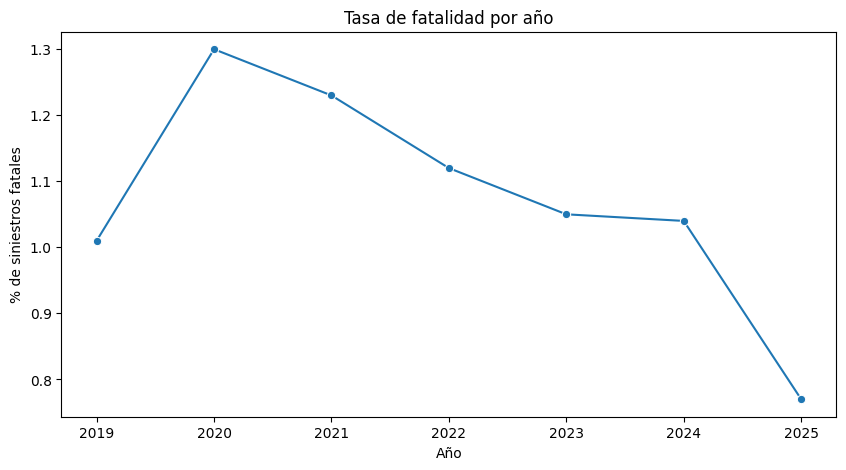

In [8]:
# Analizar la evolución anual de los siniestros y la tasa de fatalidad

resumen_anual = (
    df.groupby("anio_siniestro")
      .agg(
          siniestros=("id_siniestro", "count"),
          fatales=("siniestro_fatal", "sum")
      )
)

resumen_anual["porcentaje_fatalidad"] = round(
    resumen_anual["fatales"] / resumen_anual["siniestros"] * 100,
    2
)

display(resumen_anual)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=resumen_anual,
    x=resumen_anual.index,
    y="porcentaje_fatalidad",
    marker="o"
)

plt.title("Tasa de fatalidad por año")
plt.xlabel("Año")
plt.ylabel("% de siniestros fatales")

plt.show()

c:\Users\consul_05\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\consul_05\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


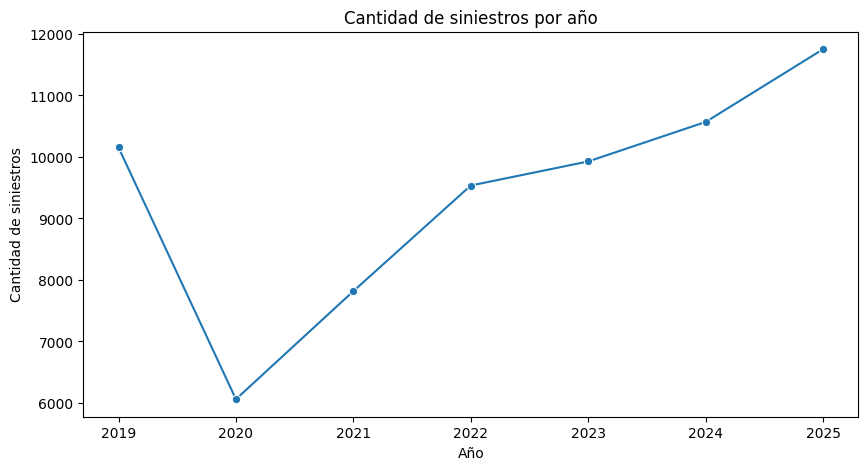

In [9]:
# Visualizar la evolución de la cantidad de siniestros por año

plt.figure(figsize=(10,5))

sns.lineplot(
    data=resumen_anual,
    x=resumen_anual.index,
    y="siniestros",
    marker="o"
)

plt.title("Cantidad de siniestros por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de siniestros")

plt.show()

**Observaciones**

La cantidad de siniestros registrados presenta una fuerte caída durante 2020, seguida por una recuperación sostenida entre 2021 y 2025. Este comportamiento podría estar asociado a las restricciones de circulación implementadas durante la pandemia de COVID-19.

A partir de 2021 se observa un crecimiento progresivo en la cantidad de siniestros, alcanzando en 2025 el mayor volumen de toda la serie analizada.

Por otra parte, la tasa de fatalidad no sigue exactamente la misma evolución que la cantidad total de siniestros. El año 2020 registra el mayor porcentaje de siniestros fatales de toda la serie (1,30%), a pesar de haber presentado la menor cantidad de hechos registrados.

Desde 2021 se observa una tendencia general descendente en la proporción de siniestros fatales, alcanzando su valor más bajo en 2025 (0,77%).

Estos resultados sugieren que la evolución temporal podría aportar información relevante para la construcción del modelo predictivo y evidencian que una mayor cantidad de siniestros no necesariamente implica una mayor proporción de eventos fatales.

### **Distribución por mes**

Se analiza la distribución de los siniestros según el mes de ocurrencia y la proporción de siniestros fatales en cada período.

El objetivo es identificar posibles patrones estacionales que puedan estar asociados con una mayor o menor frecuencia de eventos fatales.

,siniestros,fatales,porcentaje_fatalidad
mes_siniestro,,,
1,4627,61,1.32
2,4701,55,1.17
3,5652,53,0.94
4,5263,59,1.12
5,5325,65,1.22
6,5366,55,1.02
7,5528,53,0.96
8,5793,62,1.07
9,5683,55,0.97


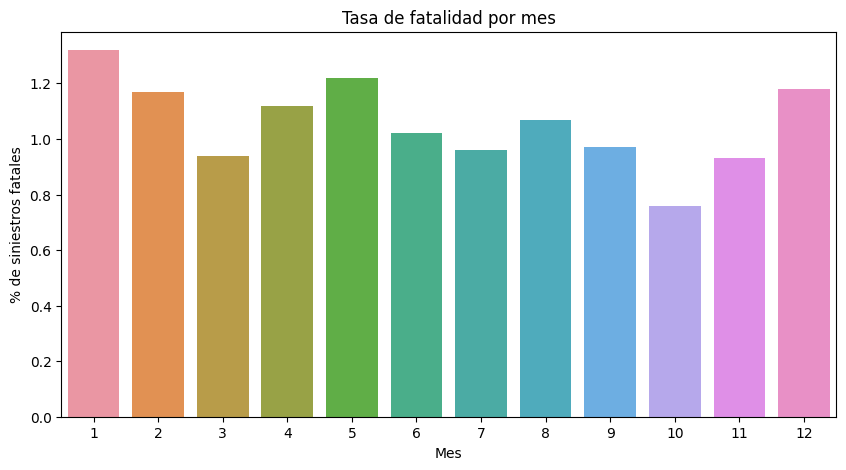

In [11]:
# Analizar la distribución mensual de los siniestros y la tasa de fatalidad

resumen_mensual = (
    df.groupby("mes_siniestro")
      .agg(
          siniestros=("id_siniestro", "count"),
          fatales=("siniestro_fatal", "sum")
      )
)

resumen_mensual["porcentaje_fatalidad"] = round(
    resumen_mensual["fatales"] / resumen_mensual["siniestros"] * 100,
    2
)

display(resumen_mensual)

plt.figure(figsize=(10,5))

sns.barplot(
    x=resumen_mensual.index,
    y=resumen_mensual["porcentaje_fatalidad"]
)

plt.title("Tasa de fatalidad por mes")
plt.xlabel("Mes")
plt.ylabel("% de siniestros fatales")

plt.show()

**Observaciones**

La distribución mensual muestra variaciones en la tasa de fatalidad a lo largo del año, aunque no se observa un patrón estacional claramente definido.

Los valores más elevados se registran en enero (1,32%), mayo (1,22%) y diciembre (1,18%), mientras que octubre presenta la menor proporción de siniestros fatales (0,76%).

En términos generales, las diferencias entre meses son moderadas y no permiten identificar una concentración evidente de la fatalidad en una estación particular del año.

Estos resultados sugieren que el mes de ocurrencia podría aportar cierta información al modelo predictivo, aunque su capacidad explicativa probablemente sea menor que la de otras variables asociadas directamente a las características del siniestro.

### **Distribución por día de la semana**

Se analiza la distribución de los siniestros según el día de ocurrencia y la proporción de siniestros fatales en cada caso.

El objetivo es identificar posibles diferencias entre días laborales y fines de semana que puedan estar asociadas a cambios en la movilidad o en los patrones de circulación.

,siniestros,fatales,porcentaje_fatalidad
dia_semana,,,
Monday,9670,94,0.97
Tuesday,10319,107,1.04
Wednesday,10391,90,0.87
Thursday,10678,123,1.15
Friday,11120,92,0.83
Saturday,7791,103,1.32
Sunday,5849,80,1.37


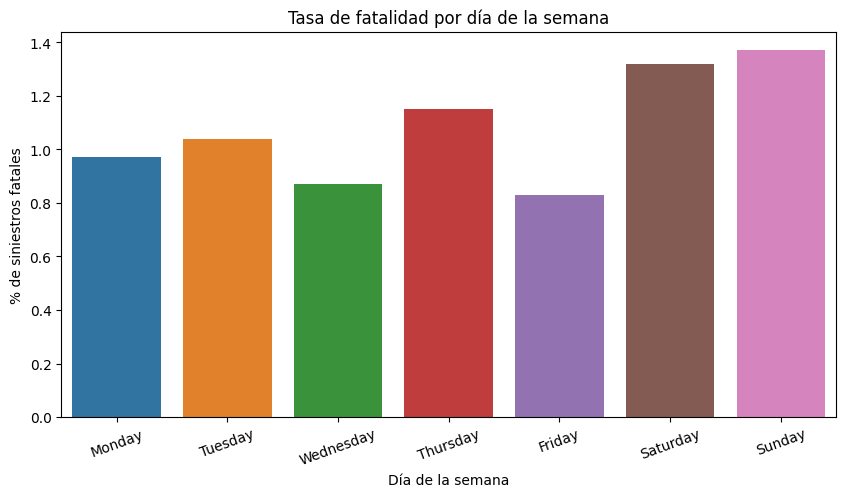

In [12]:
# Analizar la distribución por día de la semana y la tasa de fatalidad

orden_dias = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

resumen_dias = (
    df.groupby("dia_semana")
      .agg(
          siniestros=("id_siniestro", "count"),
          fatales=("siniestro_fatal", "sum")
      )
      .reindex(orden_dias)
)

resumen_dias["porcentaje_fatalidad"] = round(
    resumen_dias["fatales"] / resumen_dias["siniestros"] * 100,
    2
)

display(resumen_dias)

plt.figure(figsize=(10,5))

sns.barplot(
    x=resumen_dias.index,
    y=resumen_dias["porcentaje_fatalidad"]
)

plt.title("Tasa de fatalidad por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("% de siniestros fatales")

plt.xticks(rotation=20)

plt.show()

**Observaciones**

La distribución por día de la semana muestra diferencias más marcadas que las observadas en el análisis mensual.

Los mayores porcentajes de siniestros fatales se registran durante el fin de semana, particularmente los domingos (1,37%) y sábados (1,32%). En contraste, los menores valores corresponden a los viernes (0,83%) y miércoles (0,87%).

Resulta especialmente interesante que los fines de semana presentan una menor cantidad total de siniestros respecto de los días hábiles, pero una mayor proporción de eventos fatales.

Si bien este análisis no permite establecer relaciones causales, los resultados sugieren que el día de ocurrencia podría constituir una variable relevante para explicar la probabilidad de fatalidad de un siniestro.

En consecuencia, `dia_semana` aparece como una variable potencialmente más informativa que `mes_siniestro` para las etapas posteriores de modelado.

### **Distribución por rango horario**

Se analiza la distribución de los siniestros según el rango horario de ocurrencia y la proporción de siniestros fatales en cada caso.

El objetivo es identificar franjas horarias asociadas a una mayor probabilidad de fatalidad y evaluar si el horario constituye una variable relevante para el modelado.

,siniestros,fatales,porcentaje_fatalidad
rango_horario,,,
0,1901,19,1.00
1,947,17,1.80
2,693,13,1.88
3,508,29,5.71
4,454,23,5.07
5,754,31,4.11
6,1317,32,2.43
7,2150,44,2.05
8,2960,27,0.91


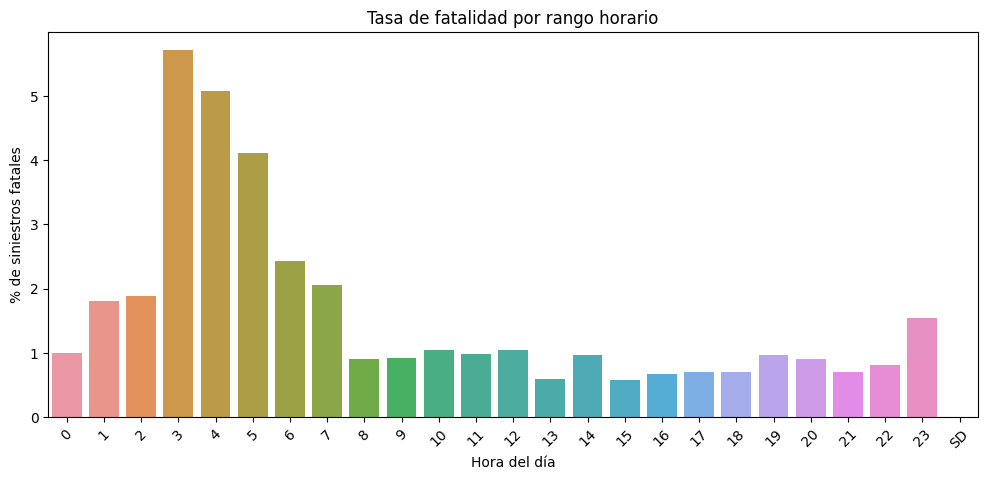

In [13]:
# Analizar la distribución por rango horario y la tasa de fatalidad

resumen_horario = (
    df.groupby("rango_horario")
      .agg(
          siniestros=("id_siniestro", "count"),
          fatales=("siniestro_fatal", "sum")
      )
)

resumen_horario["porcentaje_fatalidad"] = round(
    resumen_horario["fatales"] / resumen_horario["siniestros"] * 100,
    2
)

# Ordenar horas correctamente y dejar SD al final

orden_horas = [str(i) for i in range(24)] + ["SD"]

resumen_horario = resumen_horario.reindex(orden_horas)

display(resumen_horario)

plt.figure(figsize=(12,5))

sns.barplot(
    x=resumen_horario.index,
    y=resumen_horario["porcentaje_fatalidad"]
)

plt.title("Tasa de fatalidad por rango horario")
plt.xlabel("Hora del día")
plt.ylabel("% de siniestros fatales")

plt.xticks(rotation=45)

plt.show()

**Observaciones**

El análisis por rango horario muestra las diferencias más marcadas observadas hasta el momento entre los distintos grupos temporales.

Las mayores tasas de fatalidad se registran durante la madrugada, particularmente entre las 03:00 y las 05:00 horas. El valor máximo se observa a las 03:00 (5,71%), seguido por las 04:00 (5,07%) y las 05:00 (4,11%).

Por el contrario, durante gran parte de la tarde la proporción de siniestros fatales disminuye considerablemente, alcanzando sus valores mínimos entre las 13:00 y las 18:00 horas.

Resulta especialmente relevante que las diferencias observadas entre franjas horarias son sustancialmente superiores a las encontradas en los análisis por año, mes o día de la semana. Mientras que algunas horas presentan tasas de fatalidad superiores al 5%, otras se mantienen por debajo del 1%.

Estos resultados sugieren que el horario de ocurrencia constituye una de las variables temporales con mayor potencial explicativo para la predicción de siniestros fatales y debería ser considerada una variable relevante durante la etapa de modelado.

### **Análisis geográfico**

Las variables geográficas permiten analizar la distribución espacial de los siniestros y evaluar si existen zonas con diferentes niveles de riesgo.

En primer lugar se estudia la variable `comuna_siniestro`, analizando tanto la cantidad de siniestros registrados como la proporción de siniestros fatales en cada comuna.

In [14]:
# Normalizar categorías detectadas durante el EDA sin convertir valores nulos a texto

df["comuna_siniestro"] = (
    df["comuna_siniestro"]
      .str.upper()
      .str.replace("COMUNA ", "", regex=False)
)

df["participantes_siniestro"] = (
    df["participantes_siniestro"]
      .str.upper()
)

In [15]:
# Verificar categorías luego de la normalización

print(sorted(df["comuna_siniestro"].dropna().unique()))
print(df["comuna_siniestro"].isna().sum())

print(sorted(df["participantes_siniestro"].dropna().unique())[:10])
print("Cantidad de categorías en participantes:", df["participantes_siniestro"].nunique())

['1', '10', '11', '12', '13', '14', '15', '2', '3', '4', '5', '6', '7', '8', '9', 'SD']
3017
['AUTO-AUTO', 'AUTO-BICICLETA', 'AUTO-CAMION', 'AUTO-CAMIONETA', 'AUTO-MONOPATIN', 'AUTO-MOTO', 'AUTO-MOVIL', 'AUTO-MULTIPLE', 'AUTO-OBJETO FIJO', 'AUTO-OTRO']
Cantidad de categorías en participantes: 173


**Observaciones**

Durante el EDA se detectaron inconsistencias menores en el formato de algunas variables categóricas, principalmente asociadas al uso de mayúsculas/minúsculas y diferentes representaciones de una misma categoría.

Se realizó una normalización adicional para unificar dichas categorías y evitar la fragmentación de resultados en los análisis posteriores.

Estas correcciones no modifican el significado de los datos, sino únicamente su representación.

,siniestros,fatales,porcentaje_fatalidad
comuna_siniestro,,,
1,7241,74,1.02
10,3776,51,1.35
11,3531,30,0.85
12,4310,43,1.00
13,3965,44,1.11
14,4496,39,0.87
15,5214,44,0.84
2,2350,24,1.02
3,4858,42,0.86


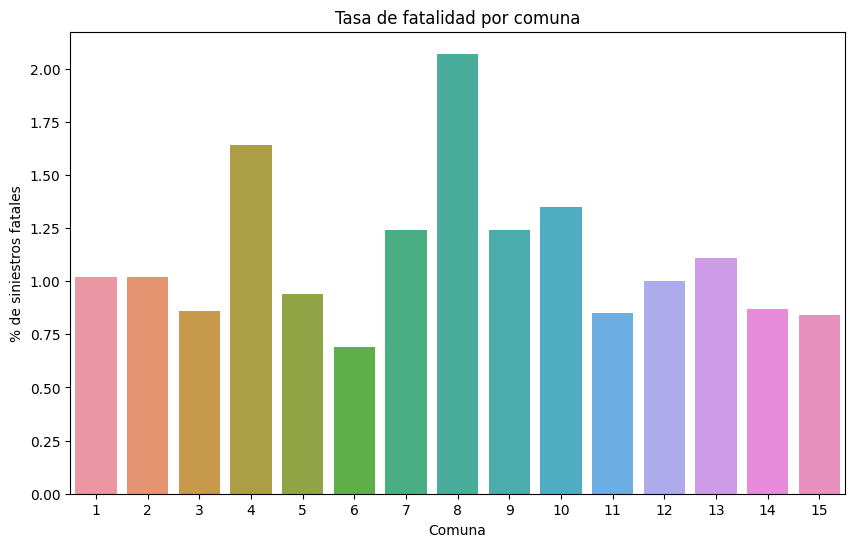

In [16]:
# Analizar la distribución por comuna y la tasa de fatalidad

resumen_comuna = (
    df.groupby("comuna_siniestro")
      .agg(
          siniestros=("id_siniestro", "count"),
          fatales=("siniestro_fatal", "sum")
      )
)

resumen_comuna["porcentaje_fatalidad"] = round(
    resumen_comuna["fatales"] / resumen_comuna["siniestros"] * 100,
    2
)

# Excluir SD para el análisis gráfico
resumen_comuna_graf = resumen_comuna.loc[
    resumen_comuna.index != "SD"
].copy()

# Ordenar comunas numéricamente
resumen_comuna_graf.index = resumen_comuna_graf.index.astype(int)
resumen_comuna_graf = resumen_comuna_graf.sort_index()

display(resumen_comuna)

plt.figure(figsize=(10,6))

sns.barplot(
    x=resumen_comuna_graf.index,
    y=resumen_comuna_graf["porcentaje_fatalidad"]
)

plt.title("Tasa de fatalidad por comuna")
plt.xlabel("Comuna")
plt.ylabel("% de siniestros fatales")

plt.show()

**Observaciones**

La distribución geográfica evidencia diferencias relevantes entre las distintas comunas de la Ciudad de Buenos Aires.

La Comuna 8 presenta la mayor tasa de fatalidad observada (2,07%), seguida por las comunas 4 (1,64%) y 10 (1,35%). En contraste, las menores proporciones de siniestros fatales corresponden a las comunas 6 (0,69%), 15 (0,84%) y 11 (0,85%).

Las diferencias observadas entre comunas son considerablemente superiores a las detectadas en el análisis mensual y sugieren que la ubicación geográfica podría estar asociada a distintos niveles de riesgo.

Si bien este análisis no permite establecer relaciones causales, los resultados indican que `comuna_siniestro` constituye una variable con potencial explicativo para la predicción de siniestros fatales y debería ser considerada en las etapas posteriores de modelado.

### **Distribución espacial de los siniestros**

Además del análisis por comuna, se explora la distribución espacial de los siniestros utilizando las coordenadas geográficas registradas para cada evento.

El objetivo es identificar visualmente posibles zonas de concentración y verificar la cobertura espacial de los registros dentro de la Ciudad Autónoma de Buenos Aires.

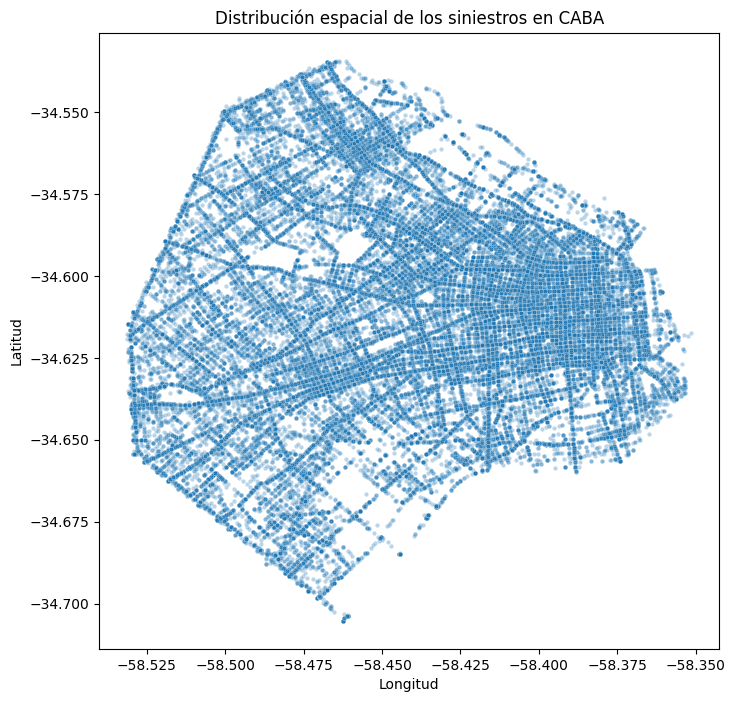

In [17]:
# Visualizar la distribución espacial de los siniestros

plt.figure(figsize=(8,8))

sns.scatterplot(
    data=df,
    x="longitud_siniestro",
    y="latitud_siniestro",
    alpha=0.3,
    s=10
)

plt.title("Distribución espacial de los siniestros en CABA")
plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.show()

**Observaciones**

La distribución espacial de los siniestros permite reconstruir visualmente la forma general de la Ciudad Autónoma de Buenos Aires a partir de las coordenadas registradas para cada evento.

Se observan concentraciones de puntos siguiendo los principales corredores de circulación, lo que resulta consistente con la ocurrencia de siniestros sobre calles, avenidas y vías de alto tránsito.

No se detectan agrupamientos anómalos ni concentraciones significativas de registros fuera del área esperada, lo que constituye una validación adicional de la calidad de las coordenadas geográficas utilizadas en el análisis.

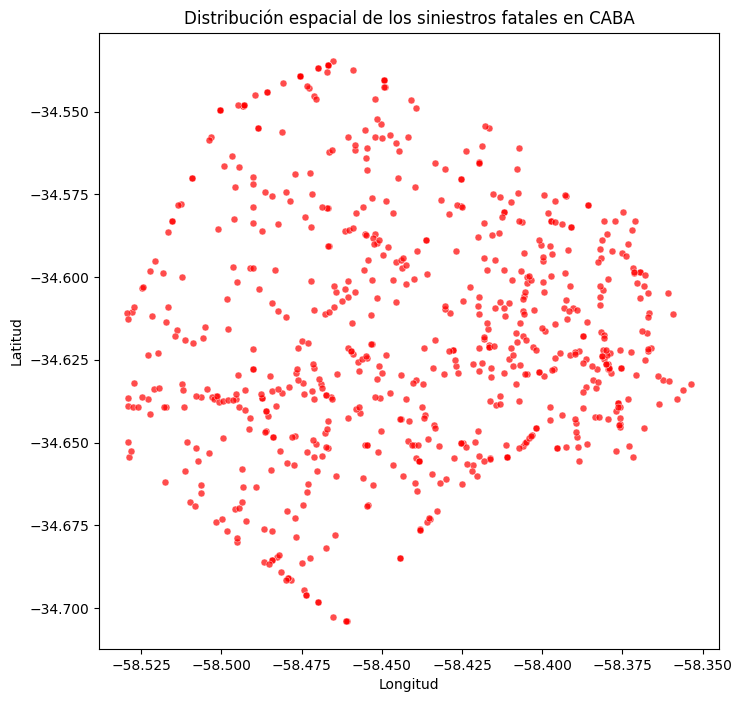

In [18]:
plt.figure(figsize=(8,8))

sns.scatterplot(
    data=df[df["siniestro_fatal"] == 1],
    x="longitud_siniestro",
    y="latitud_siniestro",
    color="red",
    alpha=0.7,
    s=25
)

plt.title("Distribución espacial de los siniestros fatales en CABA")
plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.show()

### **Participantes del siniestro**

La variable `participantes_siniestro` representa la combinación entre el tipo de víctima y la contraparte involucrada en el hecho.

Dado que existen numerosas categorías posibles, primero se analiza la frecuencia de ocurrencia de cada combinación para identificar cuáles concentran la mayor cantidad de siniestros.

In [19]:
# Analizar frecuencia de las categorías de participantes

participantes_freq = (
    df["participantes_siniestro"]
      .value_counts()
      .reset_index()
)

participantes_freq.columns = [
    "participantes_siniestro",
    "cantidad"
]

display(participantes_freq.head(20))

print(
    "Cantidad total de categorías:",
    df["participantes_siniestro"].nunique()
)

,participantes_siniestro,cantidad
0,MOTO-AUTO,15247
1,SD-SD,10348
2,PEATON-AUTO,4502
3,BICICLETA-AUTO,4067
4,AUTO-AUTO,3895
5,TRANSPORTE PUBLICO-TRANSPORTE PUBLICO,2539
6,MOTO-UTILITARIO,1750
7,MOTO-SD,1669
8,PEATON-MOTO,1567
9,MOTO-MOTO,1191


Cantidad total de categorías: 173


In [20]:
# Distribución del volumen de categorías

participantes_volumen = (
    df["participantes_siniestro"]
      .value_counts()
      .rename_axis("participantes_siniestro")
      .reset_index(name="cantidad")
)

print("Categorías con al menos 100 siniestros:",
      (participantes_volumen["cantidad"] >= 100).sum())

print("Categorías con al menos 200 siniestros:",
      (participantes_volumen["cantidad"] >= 200).sum())

print("Categorías con al menos 500 siniestros:",
      (participantes_volumen["cantidad"] >= 500).sum())

Categorías con al menos 100 siniestros: 46
Categorías con al menos 200 siniestros: 40
Categorías con al menos 500 siniestros: 23


Se analiza la tasa de fatalidad según la combinación de participantes involucrados en el siniestro.

Para evitar conclusiones basadas en categorías con escasa representatividad, el análisis se restringe a aquellas combinaciones con al menos 500 siniestros registrados.

,siniestros,fatales,porcentaje_fatalidad
participantes_siniestro,,,
MOTO-OBJETO FIJO,775,63,8.13
PEATON-TRANSPORTE PUBLICO,1102,88,7.99
MOTO-CAMION,1107,69,6.23
MOTO-TRANSPORTE PUBLICO,1044,33,3.16
PEATON-MOTO,1567,36,2.30
PEATON-AUTO,4502,90,2.00
AUTO-CAMION,546,9,1.65
MOTO-MOTO,1191,10,0.84
AUTO-TRANSPORTE PUBLICO,511,4,0.78


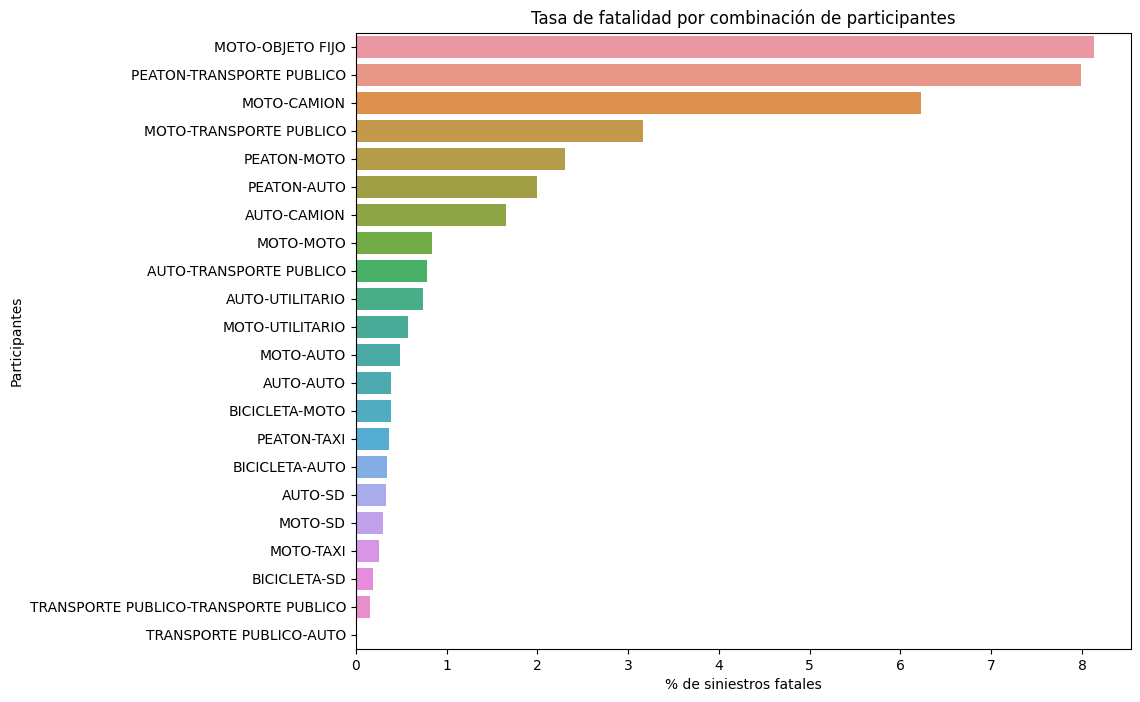

In [21]:
# Analizar fatalidad por combinación de participantes
# considerando únicamente categorías con al menos 500 siniestros

resumen_participantes = (
    df.groupby("participantes_siniestro")
      .agg(
          siniestros=("id_siniestro", "count"),
          fatales=("siniestro_fatal", "sum")
      )
)

resumen_participantes["porcentaje_fatalidad"] = round(
    resumen_participantes["fatales"] /
    resumen_participantes["siniestros"] * 100,
    2
)

resumen_participantes = (
    resumen_participantes
      .query("siniestros >= 500")
      .sort_values(
          "porcentaje_fatalidad",
          ascending=False
      )
)

display(resumen_participantes)

# Excluir SD-SD del gráfico
grafico_participantes = resumen_participantes.loc[
    resumen_participantes.index != "SD-SD"
]

plt.figure(figsize=(10,8))

sns.barplot(
    data=grafico_participantes.reset_index(),
    x="porcentaje_fatalidad",
    y="participantes_siniestro"
)

plt.title(
    "Tasa de fatalidad por combinación de participantes"
)
plt.xlabel("% de siniestros fatales")
plt.ylabel("Participantes")

plt.show()

**Observaciones**

La combinación de participantes muestra algunas de las diferencias más marcadas observadas en todo el EDA.

Las mayores tasas de fatalidad corresponden a los siniestros entre motos y objetos fijos (8,13%), peatones y transporte público (7,99%) y motos y camiones (6,23%).

También se observa una mayor proporción de siniestros fatales cuando intervienen peatones, particularmente en combinación con transporte público, motos y automóviles.

Por el contrario, las combinaciones más frecuentes, como MOTO-AUTO (0,49%) y AUTO-AUTO (0,39%), presentan tasas de fatalidad considerablemente menores.

Estos resultados sugieren que la naturaleza de los participantes involucrados constituye uno de los factores más relevantes para explicar la ocurrencia de siniestros fatales y probablemente represente una de las variables con mayor capacidad predictiva dentro del modelo.

**Contraparte del siniestro**

Se analiza la variable `contraparte_siniestro`, que identifica el tipo de vehículo o participante asociado al hecho.

El objetivo es evaluar si determinadas contrapartes aparecen con mayor frecuencia en siniestros fatales y determinar su posible relevancia para el modelado.

,siniestros,fatales,porcentaje_fatalidad
contraparte_siniestro,,,
OBJETO FIJO,1521,87,5.72
CAMION,2579,124,4.81
MULTIPLE,347,13,3.75
TRANSPORTE PUBLICO,6035,141,2.34
BICICLETA,390,6,1.54
MOTO,3496,50,1.43
OTRO,204,2,0.98
UTILITARIO,3575,34,0.95
MOVIL,804,7,0.87


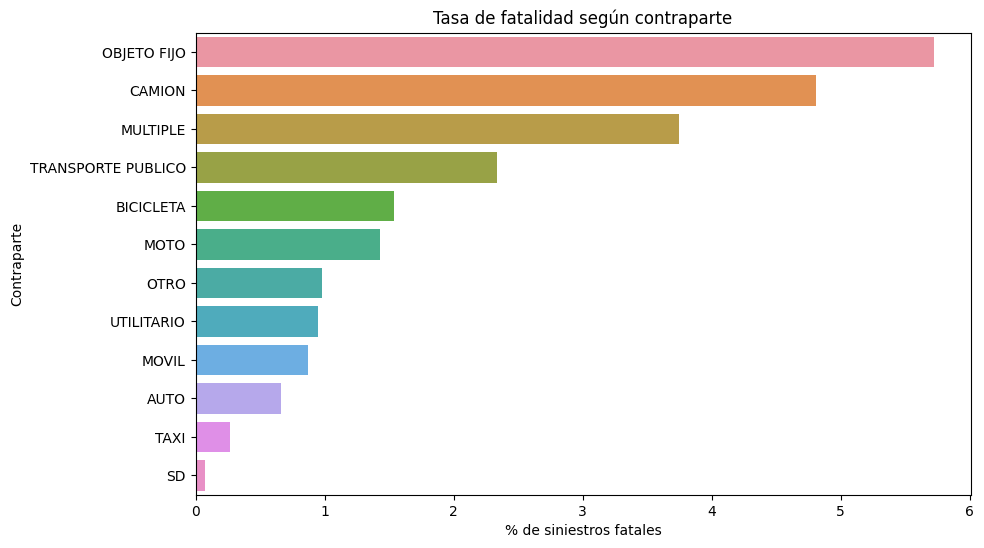

In [22]:
# Analizar fatalidad según la contraparte involucrada

resumen_contraparte = (
    df.groupby("contraparte_siniestro")
      .agg(
          siniestros=("id_siniestro", "count"),
          fatales=("siniestro_fatal", "sum")
      )
)

resumen_contraparte["porcentaje_fatalidad"] = round(
    resumen_contraparte["fatales"] /
    resumen_contraparte["siniestros"] * 100,
    2
)

# Mantener categorías con volumen razonable
resumen_contraparte = (
    resumen_contraparte
      .query("siniestros >= 100")
      .sort_values(
          "porcentaje_fatalidad",
          ascending=False
      )
)

display(resumen_contraparte)

plt.figure(figsize=(10,6))

sns.barplot(
    data=resumen_contraparte.reset_index(),
    x="porcentaje_fatalidad",
    y="contraparte_siniestro"
)

plt.title("Tasa de fatalidad según contraparte")
plt.xlabel("% de siniestros fatales")
plt.ylabel("Contraparte")

plt.show()

**Observaciones**

La variable `contraparte_siniestro` presenta diferencias significativas en la proporción de siniestros fatales según el tipo de participante involucrado.

Las mayores tasas de fatalidad se observan cuando la contraparte corresponde a un objeto fijo (5,72%), un camión (4,81%), múltiples participantes (3,75%) o transporte público (2,34%).

Estos resultados son consistentes con los hallazgos obtenidos en el análisis de combinaciones de participantes, donde también se observó una mayor proporción de fatalidad en siniestros que involucraban camiones, transporte público u objetos fijos.

Por el contrario, las contrapartes más frecuentes, como los automóviles (0,66%), presentan tasas de fatalidad considerablemente menores.

En conjunto, la evidencia sugiere que el tipo de contraparte constituye una variable relevante para explicar la ocurrencia de siniestros fatales y podría aportar información valiosa durante la etapa de modelado.

**Modo de desplazamiento de la víctima**

Se analiza la variable `modo_desplazamiento_victima`, que identifica el tipo de usuario de la vía afectado en el siniestro.

El objetivo es evaluar si determinados modos de desplazamiento presentan una mayor proporción de siniestros fatales y determinar su posible relevancia para el modelo predictivo.

,siniestros,fatales,porcentaje_fatalidad
modo_desplazamiento_victima,,,
PEATON,9415,269,2.86
CAMION,250,4,1.60
MOTO,24556,285,1.16
UTILITARIO,697,8,1.15
AUTO,7073,56,0.79
BICICLETA,7091,54,0.76
MOVIL,531,3,0.56
MONOPATIN,207,1,0.48
MIXTO,498,2,0.40


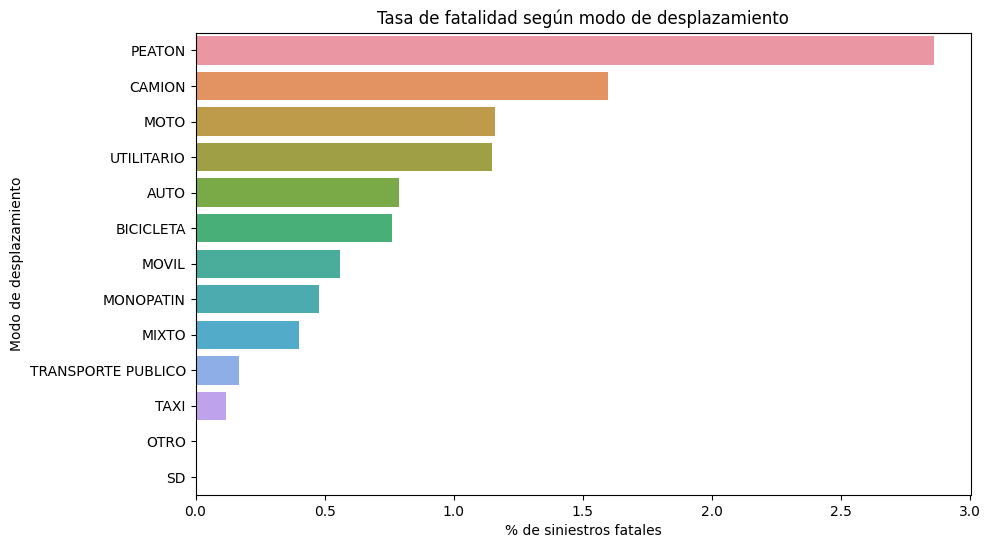

In [23]:
# Analizar fatalidad según el modo de desplazamiento de la víctima

resumen_modo = (
    df.groupby("modo_desplazamiento_victima")
      .agg(
          siniestros=("id_siniestro", "count"),
          fatales=("siniestro_fatal", "sum")
      )
)

resumen_modo["porcentaje_fatalidad"] = round(
    resumen_modo["fatales"] /
    resumen_modo["siniestros"] * 100,
    2
)

resumen_modo = (
    resumen_modo
      .sort_values(
          "porcentaje_fatalidad",
          ascending=False
      )
)

display(resumen_modo)

plt.figure(figsize=(10,6))

sns.barplot(
    data=resumen_modo.reset_index(),
    x="porcentaje_fatalidad",
    y="modo_desplazamiento_victima"
)

plt.title("Tasa de fatalidad según modo de desplazamiento")
plt.xlabel("% de siniestros fatales")
plt.ylabel("Modo de desplazamiento")

plt.show()

**Observaciones**

La variable `modo_desplazamiento_victima` muestra diferencias relevantes en la proporción de siniestros fatales según el tipo de usuario involucrado.

Los peatones presentan la mayor tasa de fatalidad observada (2,86%), seguidos por los ocupantes de camiones (1,60%) y motocicletas (1,16%).

Por el contrario, los usuarios de transporte público (0,17%), taxis (0,12%) y otros modos presentan proporciones considerablemente menores.

Los resultados sugieren que la vulnerabilidad física asociada a determinados modos de desplazamiento podría influir en la gravedad de las consecuencias de un siniestro.

Sin embargo, las diferencias observadas resultan menos pronunciadas que las identificadas en la variable `participantes_siniestro`, lo que indica que la interacción entre víctima y contraparte aporta información adicional relevante para explicar la ocurrencia de siniestros fatales.

### **Edad promedio de las víctimas**

Se analiza la distribución de la variable `edad_promedio_victimas`, que representa la edad promedio de las víctimas involucradas en cada siniestro.

El objetivo es comprender su comportamiento general y evaluar posteriormente si existen diferencias entre los siniestros fatales y no fatales.

count    45259.000000
mean        38.137487
std         15.446958
min          0.000000
25%         27.000000
50%         35.000000
75%         47.000000
max        116.000000
Name: edad_promedio_victimas, dtype: float64

c:\Users\consul_05\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


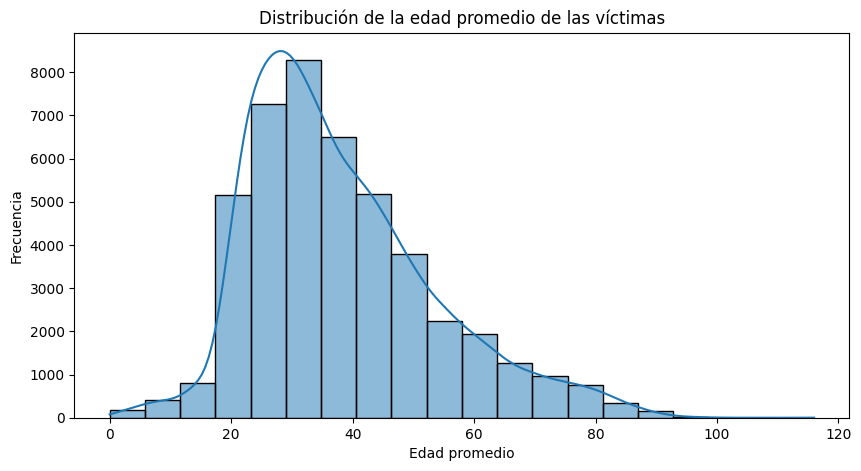

In [24]:
# Analizar la distribución de la edad promedio de las víctimas

display(
    df["edad_promedio_victimas"].describe()
)

plt.figure(figsize=(10,5))

sns.histplot(
    df["edad_promedio_victimas"],
    bins=20,
    kde=True
)

plt.title("Distribución de la edad promedio de las víctimas")
plt.xlabel("Edad promedio")
plt.ylabel("Frecuencia")

plt.show()

Se compara la distribución de la edad promedio de las víctimas entre los siniestros fatales y no fatales para evaluar si existen diferencias relevantes entre ambos grupos.

,count,mean,std,min,25%,50%,75%,max
siniestro_fatal,,,,,,,,
0,44599.0,38.032292,15.335216,0.0,27.0,35.0,47.0,116.0
1,660.0,45.245934,20.503547,2.0,28.0,40.5,60.0,97.0


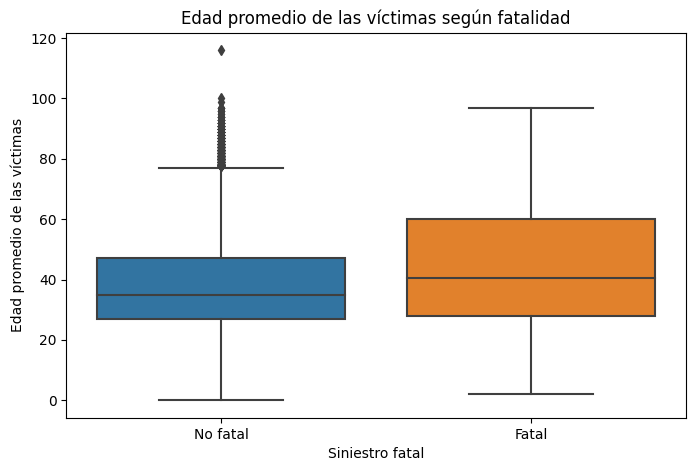

In [25]:
# Comparar edad promedio según fatalidad

resumen_edad_fatalidad = (
    df.groupby("siniestro_fatal")["edad_promedio_victimas"]
      .describe()
)

display(resumen_edad_fatalidad)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="siniestro_fatal",
    y="edad_promedio_victimas"
)

plt.title(
    "Edad promedio de las víctimas según fatalidad"
)

plt.xlabel(
    "Siniestro fatal"
)

plt.ylabel(
    "Edad promedio de las víctimas"
)

plt.xticks(
    [0, 1],
    ["No fatal", "Fatal"]
)

plt.show()

**Observaciones**

La comparación entre siniestros fatales y no fatales muestra diferencias relevantes en la edad promedio de las víctimas.

Los siniestros fatales presentan una edad promedio superior (45,2 años) respecto de los siniestros no fatales (38,0 años). Esta diferencia también se observa en la mediana, que aumenta de 35 a 40,5 años.

El boxplot evidencia además una mayor dispersión de edades en los siniestros fatales y una mayor presencia de víctimas de edades avanzadas.

Estos resultados sugieren que la edad promedio de las víctimas podría estar asociada a una mayor probabilidad de fatalidad y constituye una variable potencialmente relevante para el modelo predictivo.

### **Sexo de las víctimas**

Se analiza la variable `sexo_victima_agregado`, que representa el sexo predominante entre las víctimas asociadas a cada siniestro.

El objetivo es evaluar si existen diferencias en la proporción de siniestros fatales según esta característica.

,siniestros,fatales,porcentaje_fatalidad
sexo_victima_agregado,,,
M,32720,502,1.53
F,15205,163,1.07
MIXTO,2905,23,0.79
SD,14988,1,0.01


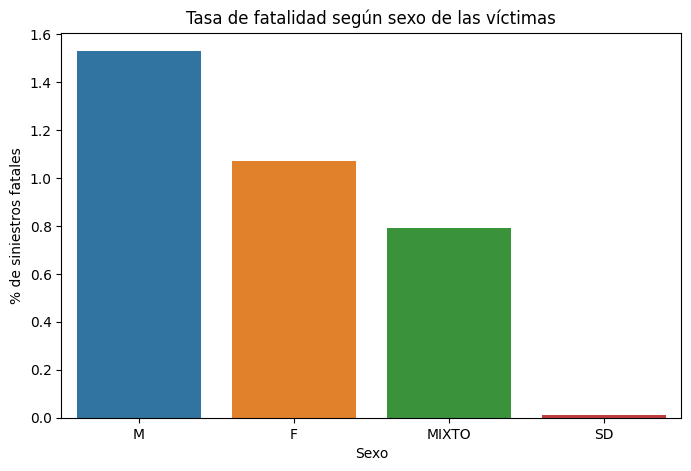

In [26]:
# Analizar fatalidad según sexo de las víctimas

resumen_sexo = (
    df.groupby("sexo_victima_agregado")
      .agg(
          siniestros=("id_siniestro", "count"),
          fatales=("siniestro_fatal", "sum")
      )
)

resumen_sexo["porcentaje_fatalidad"] = round(
    resumen_sexo["fatales"] /
    resumen_sexo["siniestros"] * 100,
    2
)

resumen_sexo = (
    resumen_sexo
      .sort_values(
          "porcentaje_fatalidad",
          ascending=False
      )
)

display(resumen_sexo)

plt.figure(figsize=(8,5))

sns.barplot(
    data=resumen_sexo.reset_index(),
    x="sexo_victima_agregado",
    y="porcentaje_fatalidad"
)

plt.title(
    "Tasa de fatalidad según sexo de las víctimas"
)

plt.xlabel(
    "Sexo"
)

plt.ylabel(
    "% de siniestros fatales"
)

plt.show()

**Observaciones**

La variable `sexo_victima_agregado` muestra diferencias moderadas en la proporción de siniestros fatales.

Los siniestros asociados a víctimas masculinas presentan la mayor tasa de fatalidad observada (1,53%), seguidos por aquellos asociados a víctimas femeninas (1,07%).

Si bien las diferencias son menos pronunciadas que las observadas en variables como participantes, contraparte o rango horario, los resultados sugieren que el sexo de las víctimas podría aportar información complementaria durante el modelado.

La categoría `SD` presenta una cantidad considerable de registros con información insuficiente, por lo que sus resultados deben interpretarse con cautela.

### **Principales hallazgos del análisis exploratorio**

El análisis exploratorio permitió identificar patrones relevantes asociados a la ocurrencia de siniestros fatales en la Ciudad Autónoma de Buenos Aires.

Entre los principales hallazgos se destacan:

- La tasa de fatalidad presenta una tendencia descendente en los años más recientes del período analizado.
- No se observa una estacionalidad mensual marcada en la ocurrencia de siniestros fatales.
- Los fines de semana, especialmente sábados y domingos, presentan una mayor proporción de siniestros fatales respecto de los días hábiles.
- La madrugada concentra las mayores tasas de fatalidad, alcanzando sus valores máximos entre las 03:00 y las 05:00 horas.
- Existen diferencias geográficas relevantes entre comunas, destacándose la Comuna 8 como la de mayor proporción de siniestros fatales.
- Las combinaciones de participantes muestran algunas de las diferencias más pronunciadas observadas en todo el análisis, particularmente en siniestros que involucran motos, peatones, camiones, transporte público u objetos fijos.
- Las contrapartes asociadas a mayores niveles de fatalidad corresponden a objetos fijos, camiones y transporte público.
- Los peatones constituyen el grupo con mayor proporción de siniestros fatales según el modo de desplazamiento.
- Los siniestros fatales presentan víctimas de mayor edad promedio que los siniestros no fatales.
- Los siniestros asociados a víctimas masculinas presentan una mayor proporción de fatalidad que aquellos asociados a víctimas femeninas.

En conjunto, los resultados sugieren que las variables relacionadas con los participantes involucrados, el horario de ocurrencia y las características de las víctimas poseen un elevado potencial explicativo para la predicción de siniestros fatales y deberían recibir especial atención durante la etapa de modelado.

In [27]:
# Exportar el dataset actualizado luego de los ajustes realizados durante el EDA

df.to_csv(
    "../data_processed/siniestros_viales_modelado.csv",
    index=False
)

df.to_excel(
    "../data_processed/siniestros_viales_modelado.xlsx",
    index=False
)

print("Dataset actualizado exportado correctamente.")

Dataset actualizado exportado correctamente.


Durante el EDA se realizaron ajustes menores de normalización en `comuna_siniestro` y `participantes_siniestro`. Luego de estos ajustes, el dataset analítico fue exportado nuevamente a `siniestros_viales_modelado.csv` y `siniestros_viales_modelado.xlsx`.